# Wine Quality Analysis — Red Wine (Classification & Regression)

## Objective

Predict red wine quality using both classification and regression approaches based on physicochemical properties.

- **Classification**: Predict quality categories (Low / Medium / High)
- **Regression**: Predict the original quality score (observed range: 3–8)

## Design Decisions

- **Label regrouping for classification**:
  - Low: quality ≤ 5
  - Medium: quality = 6
  - High: quality ≥ 7

- **Separate analysis**:
  - Red and white wines are analysed separately because their physicochemical distributions differ.

- **Six models are evaluated**:
  - Classification: GaussianNB, Logistic Regression, Random Forest Classifier
  - Regression: Linear Regression, Random Forest Regressor, Gradient Boosting Regressor

- **Evaluation metrics**:
  - Classification: macro-F1 and accuracy
  - Regression: RMSE, MAE, and R²

## Improvements Implemented

- Data exploration (EDA) and feature analysis
- Missing value and duplicate checks, with duplicates removed
- Correlation analysis
- Outlier-robust scaling using `RobustScaler` for Logistic Regression
- Feature scaling using `StandardScaler` for Linear Regression
- Class weighting to handle classification imbalance
- Stratified 5-fold cross-validation for classification
- 5-fold cross-validation for regression
- `GridSearchCV` hyperparameter tuning
- Overfitting analysis using train vs test performance
- Error analysis using confusion matrices and residual plots

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, KFold
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score
)

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

## Load Red Wine Dataset

In [ ]:
!unzip wine+quality.zip -d wine+quality

Archive:  wine+quality.zip
  inflating: wine+quality/winequality-red.csv  
  inflating: wine+quality/winequality-white.csv  
  inflating: wine+quality/winequality.names  


In [ ]:
RED_PATH = "wine+quality/winequality-red.csv"

df = pd.read_csv(RED_PATH, sep=";")

print("Red wine dataset shape:", df.shape)
display(df.head())
display(df.describe())

Red wine dataset shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## Data Quality Checks

We check:
- missing values
- duplicate rows

Duplicates (if any) are removed to avoid data leakage / repeated samples affecting training.

In [ ]:
print("Missing values per column:")
print(df.isna().sum())

dup_count = df.duplicated().sum()
print("\nDuplicate rows BEFORE removal:", dup_count)

if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)

print("Shape AFTER duplicate removal:", df.shape)
print("Duplicate rows AFTER removal:", df.duplicated().sum())

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicate rows BEFORE removal: 240
Shape AFTER duplicate removal: (1359, 12)
Duplicate rows AFTER removal: 0


## Label Transformation (Regrouping)

The original quality score is regrouped into 3 classes:
- Low (≤5), Medium (=6), High (≥7)

Rationale:
- Reduces sensitivity to label noise (wine ratings are subjective).
- Improves interpretability as a classification task.

In [ ]:
def regroup_quality(q: int) -> str:
    if q <= 5:
        return "Low"
    elif q == 6:
        return "Medium"
    else:
        return "High"

df["quality_label"] = df["quality"].apply(regroup_quality)

print("Original quality distribution:")
print(df["quality"].value_counts().sort_index())

print("\nRegrouped label distribution:")
print(df["quality_label"].value_counts())

Original quality distribution:
quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

Regrouped label distribution:
quality_label
Low       640
Medium    535
High      184
Name: count, dtype: int64


## EDA: Class Distribution (Imbalance)

We visualise label distribution to justify:
- **macro-F1** as primary metric
- **class_weight** for imbalance handling

For red wine, the High-quality class is a minority class, indicating moderate imbalance.
Therefore, accuracy alone may be misleading.
Class imbalance is checked for the classification target because Low, Medium, and High labels may not be equally represented. For regression, the original quality score is kept as a continuous/ordinal target.

,count,percent(%)
quality_label,,
Low,640,47.09
Medium,535,39.37
High,184,13.54


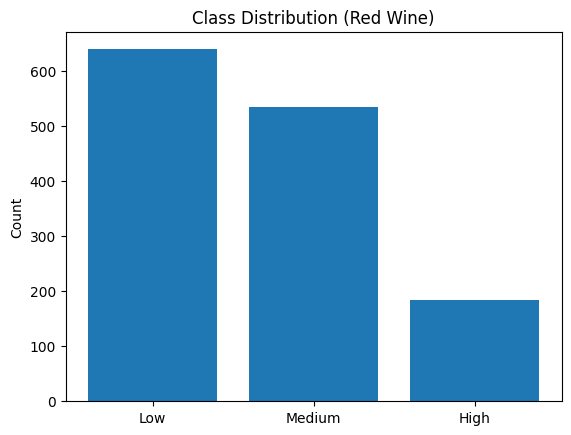

In [ ]:
counts = df["quality_label"].value_counts()
pct = df["quality_label"].value_counts(normalize=True) * 100

display(pd.DataFrame({"count": counts, "percent(%)": pct.round(2)}))

plt.figure()
plt.bar(counts.index, counts.values)
plt.title("Class Distribution (Red Wine)")
plt.ylabel("Count")
plt.show()

## EDA: Feature Distributions (Outlier Evidence)

We plot feature distributions to observe skew and potential extreme values.
Because some features can contain outliers/skewness, we adopt **RobustScaler**
for scale-sensitive models (e.g., Logistic Regression).
RobustScaler uses median and IQR, which is less sensitive to outliers than StandardScaler.

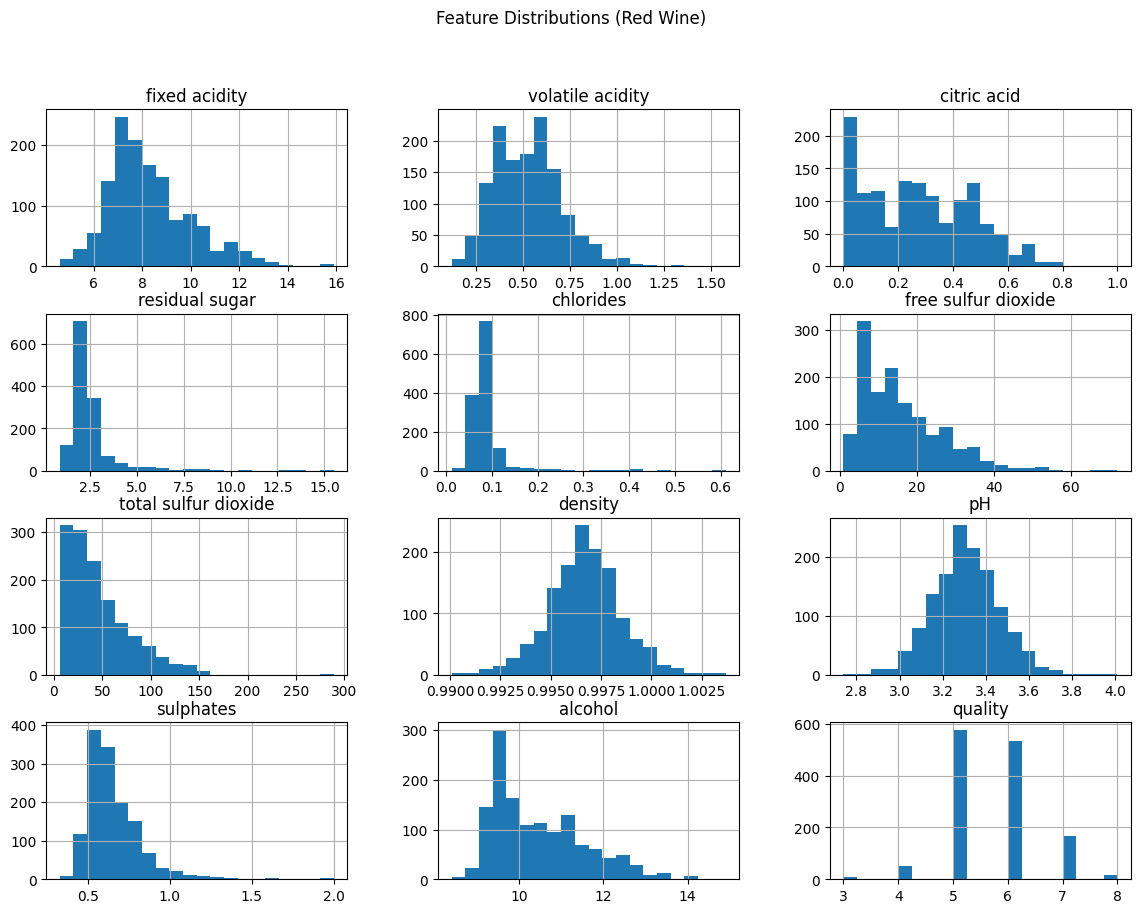

In [ ]:
df.drop(columns=["quality_label"]).hist(bins=20, figsize=(14, 10))
plt.suptitle("Feature Distributions (Red Wine)")
plt.show()

## Feature Analysis: Correlation

We examine:
1) **Feature–feature correlations** (multicollinearity evidence)
2) **Feature–quality correlation** (interpretability)

This supports explanation during Q&A and motivates why nonlinear models may perform better.
Note: correlation indicates association, not causation.

In [ ]:
X_corr = df.drop(columns=["quality", "quality_label"])
corr_x = X_corr.corr(numeric_only=True).abs()
np.fill_diagonal(corr_x.values, 0)

top_pairs = (
    corr_x.unstack()
          .sort_values(ascending=False)
          .drop_duplicates()
          .head(10)
)
print("Top 10 feature-feature correlations (absolute):")
print(top_pairs)

# (2) Feature-quality correlation
corr_all = df.drop(columns=["quality_label"]).corr(numeric_only=True)
quality_corr = corr_all["quality"].sort_values(ascending=False)

print("\nTop positive correlations with quality:")
print(quality_corr.head(6))

print("\nTop negative correlations with quality:")
print(quality_corr.tail(6))

Top 10 feature-feature correlations (absolute):
fixed acidity        pH                      0.686685
                     density                 0.670195
                     citric acid             0.667437
free sulfur dioxide  total sulfur dioxide    0.667246
volatile acidity     citric acid             0.551248
citric acid          pH                      0.550310
density              alcohol                 0.504995
sulphates            chlorides               0.394557
density              citric acid             0.357962
pH                   density                 0.355617
dtype: float64

Top positive correlations with quality:
quality           1.000000
alcohol           0.480343
sulphates         0.248835
citric acid       0.228057
fixed acidity     0.119024
residual sugar    0.013640
Name: quality, dtype: float64

Top negative correlations with quality:
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -

## Train/Test Split

We keep 20% of the dataset as a held-out test set for final evaluation only.  
The same feature split is shared by both classification and regression models so that all six models are evaluated on the same training and test samples.

The training set is used for:

- cross-validation benchmarking
- GridSearchCV hyperparameter tuning
- model fitting

For classification, stratification is applied using the regrouped quality labels to preserve the Low / Medium / High class proportions in both training and test sets.

In [ ]:
# Features
X = df.drop(columns=["quality", "quality_label"])

# Targets
y_cls = df["quality_label"]   # Classification target: Low / Medium / High
y_reg = df["quality"]         # Regression target: original quality score

# Shared train/test split for both classification and regression
X_train, X_test, y_train_cls, y_test_cls, y_train_reg, y_test_reg = train_test_split(
    X, y_cls, y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

print("Classification target:")
print("y_train_cls shape:", y_train_cls.shape)
print("y_test_cls shape: ", y_test_cls.shape)

print("\nRegression target:")
print("y_train_reg shape:", y_train_reg.shape)
print("y_test_reg shape: ", y_test_reg.shape)

X_train shape: (1087, 11)
X_test shape:  (272, 11)
Classification target:
y_train_cls shape: (1087,)
y_test_cls shape:  (272,)

Regression target:
y_train_reg shape: (1087,)
y_test_reg shape:  (272,)


## Classification Models (3 Models as Required)

- **GaussianNB**: probabilistic baseline.
- **Logistic Regression**: linear classifier baseline (RobustScaler + class_weight).
- **Random Forest**: nonlinear ensemble model (class_weight).

This comparison tests whether relationships are primarily linear or nonlinear.

In [ ]:
models = {
    "GaussianNB": GaussianNB(),

    "LogisticRegression": Pipeline([
        ("scaler", RobustScaler()),
        ("clf", LogisticRegression(
            max_iter=4000,
            solver="lbfgs",
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        random_state=42
    )
}

## Stratified 5-Fold Cross-Validation

Cross-validation reduces dependence on a single train–test split
and provides a more reliable estimate of model generalisation performance.

Primary metric: **macro-F1** (handles imbalance by weighting each class equally).
Secondary metric: accuracy (reference only).

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "acc": "accuracy",
    "f1_macro": "f1_macro",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro"
}

rows = []
for name, model in models.items():
    out = cross_validate(model, X_train, y_train_cls, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({
        "Model": name,
        "CV_Acc_mean": out["test_acc"].mean(),
        "CV_Acc_std": out["test_acc"].std(),
        "CV_F1macro_mean": out["test_f1_macro"].mean(),
        "CV_F1macro_std": out["test_f1_macro"].std(),
        "CV_Prec_macro_mean": out["test_precision_macro"].mean(),
        "CV_Rec_macro_mean": out["test_recall_macro"].mean(),
    })

cv_table = pd.DataFrame(rows).sort_values("CV_F1macro_mean", ascending=False)
display(cv_table)

,Model,CV_Acc_mean,CV_Acc_std,CV_F1macro_mean,CV_F1macro_std,CV_Prec_macro_mean,CV_Rec_macro_mean
2,RandomForest,0.672532,0.028254,0.618453,0.037074,0.670216,0.599814
1,LogisticRegression,0.602575,0.023788,0.570616,0.019916,0.566026,0.623709
0,GaussianNB,0.601700,0.027820,0.562348,0.037082,0.571902,0.562189


## GridSearchCV for Parameter Tuning (Random Forest)

We tune Random Forest using GridSearchCV.
Optimisation objective: **macro-F1**.

To avoid excessive tuning and overfitting risk,
we tune the strongest model family rather than tuning all models.

Alcohol shows the strongest positive relationship with wine quality,
suggesting higher alcohol concentration is associated with better-rated wines.
In contrast, volatile acidity exhibits a strong negative correlation,
indicating that excessive acidity tends to reduce perceived quality.

These findings align with known wine chemistry relationships and support
the interpretability of the dataset.

In [ ]:
rf = RandomForestClassifier(
    class_weight="balanced_subsample",
    random_state=42
)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.6, 1.0]
}

grid = GridSearchCV(
    rf,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train_cls)

best_rf_clf = grid.best_estimator_
print("Best params:", grid.best_params_)
print("Best CV macro-F1:", grid.best_score_)

Best params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}
Best CV macro-F1: 0.6230611653260252


## Overfitting Analysis

We compare:
- Training vs test macro-F1
- Best CV macro-F1 vs test macro-F1

A large gap suggests overfitting; a small gap indicates better generalisation.

In [ ]:
best_rf_clf.fit(X_train, y_train_cls)

train_pred_cls = best_rf_clf.predict(X_train)
test_pred_cls = best_rf_clf.predict(X_test)

train_f1 = f1_score(y_train_cls, train_pred_cls, average="macro")
test_f1 = f1_score(y_test_cls, test_pred_cls, average="macro")

train_acc = accuracy_score(y_train_cls, train_pred_cls)
test_acc = accuracy_score(y_test_cls, test_pred_cls)

print("Train macro-F1:", round(train_f1, 4), " Train Acc:", round(train_acc, 4))
print("Test  macro-F1:", round(test_f1, 4), " Test  Acc:", round(test_acc, 4))
print("Best CV macro-F1 (GridSearch):", round(grid.best_score_, 4))

# Optional quick interpretation print
gap = train_f1 - test_f1
print("Macro-F1 gap (train - test):", round(gap, 4))

cv_overfit = cross_validate(
    best_rf_clf, X_train, y_train_cls,
    cv=cv,
    scoring="f1_macro",
    return_train_score=True,
    n_jobs=-1
)

print("CV train macro-F1 mean:", round(cv_overfit["train_score"].mean(), 4))
print("CV valid macro-F1 mean:", round(cv_overfit["test_score"].mean(), 4))
print("CV gap (train - valid):", round((cv_overfit["train_score"].mean() - cv_overfit["test_score"].mean()), 4))

Train macro-F1: 0.9892  Train Acc: 0.9899
Test  macro-F1: 0.5931  Test  Acc: 0.6213
Best CV macro-F1 (GridSearch): 0.6231
Macro-F1 gap (train - test): 0.3961
CV train macro-F1 mean: 0.9838
CV valid macro-F1 mean: 0.6231
CV gap (train - valid): 0.3607


## Final Evaluation & Error Analysis (Held-out Test)

We report:
- classification report (precision/recall/F1 per class)
- confusion matrix (raw)
- confusion matrix (normalized)
- top confusion pairs (True → Pred)

Most mistakes are expected between adjacent classes (Medium ↔ High),
reflecting overlapping chemical profiles and subjective scoring.

=== Classification Report (Test) ===
              precision    recall  f1-score   support

         Low     0.7040    0.6875    0.6957       128
      Medium     0.5238    0.6168    0.5665       107
        High     0.7143    0.4054    0.5172        37

    accuracy                         0.6213       272
   macro avg     0.6474    0.5699    0.5931       272
weighted avg     0.6345    0.6213    0.6206       272



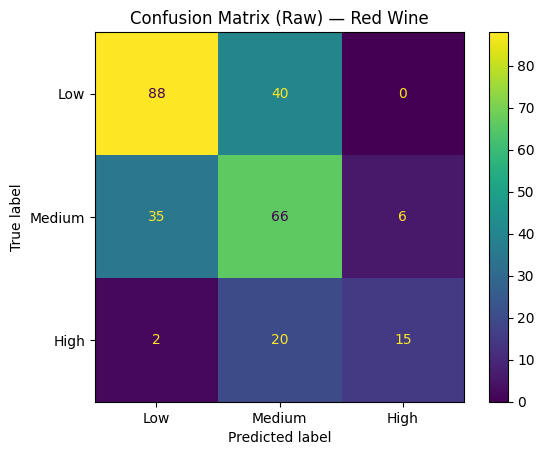

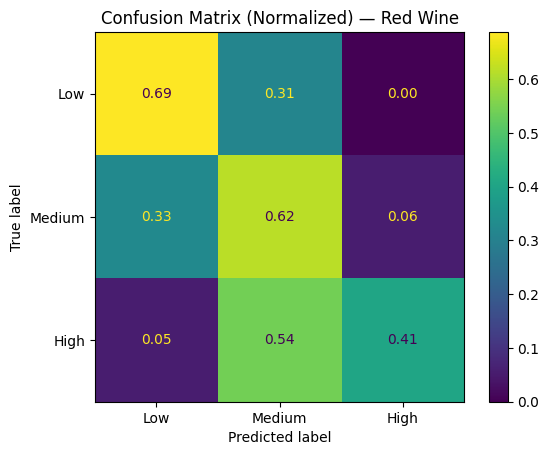

Top confusions (True -> Pred):
Low -> Medium: 40
Medium -> Low: 35
High -> Medium: 20


In [ ]:
print("=== Classification Report (Test) ===")
labels = ["Low", "Medium", "High"]
print(classification_report(y_test_cls, test_pred_cls, labels=labels, digits=4))

cm = confusion_matrix(y_test_cls, test_pred_cls, labels=labels)

ConfusionMatrixDisplay(cm, display_labels=labels).plot(values_format="d")
plt.title("Confusion Matrix (Raw) — Red Wine")
plt.show()

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=labels).plot(values_format=".2f")
plt.title("Confusion Matrix (Normalized) — Red Wine")
plt.show()

pairs = []
for i, t in enumerate(labels):
    for j, p in enumerate(labels):
        if i != j:
            pairs.append((t, p, cm[i, j]))
pairs.sort(key=lambda x: x[2], reverse=True)

print("Top confusions (True -> Pred):")
for a, b, c in pairs[:3]:
    print(f"{a} -> {b}: {c}")

## Test Set Comparison

We confirm stratification worked by checking test label distribution.
This supports fairness when comparing models and interpreting per-class performance.

In [ ]:
test_counts = y_test_cls.value_counts()
test_pct = y_test_cls.value_counts(normalize=True) * 100
display(pd.DataFrame({"test_count": test_counts, "test_percent(%)": test_pct.round(2)}))

,test_count,test_percent(%)
quality_label,,
Low,128,47.06
Medium,107,39.34
High,37,13.60


## Feature Importance (Random Forest)

Random Forest provides feature importance scores.
This supports interpretability: identifying which chemical properties contribute most to classification.

,0
alcohol,0.193619
sulphates,0.134895
volatile acidity,0.103361
total sulfur dioxide,0.088035
density,0.087111
citric acid,0.078932
chlorides,0.070668
fixed acidity,0.065520
pH,0.064749
free sulfur dioxide,0.057134


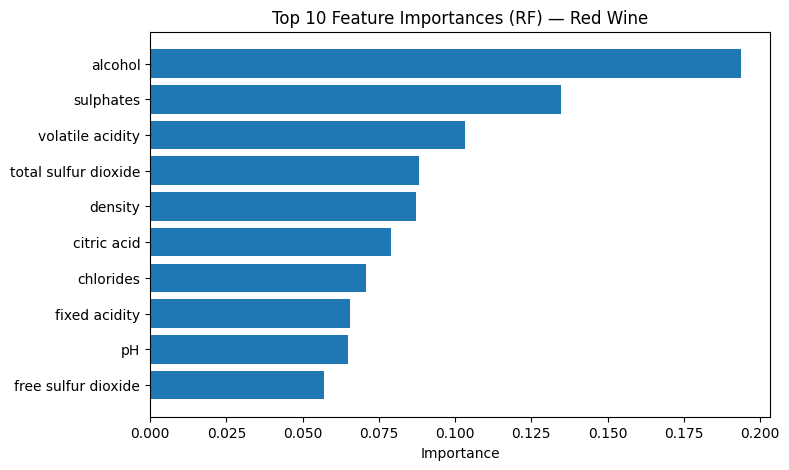

In [ ]:
importances = best_rf_clf.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

display(feat_imp.head(10))

plt.figure(figsize=(8, 5))
plt.barh(feat_imp.index[:10][::-1], feat_imp.values[:10][::-1])
plt.title("Top 10 Feature Importances (RF) — Red Wine")
plt.xlabel("Importance")
plt.show()

## Regression Models (3 Models as Required)

- **Linear Regression**: baseline regression model to capture linear relationships between features and wine quality.
- **Random Forest Regressor**: nonlinear ensemble model that captures complex feature interactions and reduces overfitting through averaging.
- **Gradient Boosting Regressor**: advanced boosting model that sequentially improves predictions and captures complex nonlinear patterns.

This comparison tests whether relationships are primarily linear or nonlinear.

## Linear Regression

Linear Regression is the baseline model. It models wine quality as a weighted sum of features:

$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_{11} x_{11}$$

The model minimises Mean Squared Error (MSE) via Ordinary Least Squares (OLS).
StandardScaler is used inside a Pipeline since Linear Regression is sensitive to feature scale.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

reg_cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# Pipeline: StandardScaler + LinearRegression
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])

param_grid_lr = {
    "linreg__fit_intercept": [True, False]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid_lr,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train_reg)

print("Best Parameters:", lr_grid.best_params_)
print("Best CV RMSE:", round(np.sqrt(-lr_grid.best_score_), 4))

Best Parameters: {'linreg__fit_intercept': True}
Best CV RMSE: 0.6665


In [ ]:
# Prediction
best_lr_reg = lr_grid.best_estimator_
y_pred_lr = best_lr_reg.predict(X_test)

In [ ]:
# Evaluation
lr_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))
lr_mae  = mean_absolute_error(y_test_reg, y_pred_lr)
lr_r2   = r2_score(y_test_reg, y_pred_lr)

print(f"RMSE : {lr_rmse:.4f}")
print(f"MAE  : {lr_mae:.4f}")
print(f"R2   : {lr_r2:.4f}")

RMSE : 0.6629
MAE  : 0.5258
R2   : 0.3294


In [ ]:
# Overfitting check
y_train_pred_lr = best_lr_reg.predict(X_train)
y_test_pred_lr  = best_lr_reg.predict(X_test)

train_rmse_lr = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_lr))
test_rmse_lr = np.sqrt(mean_squared_error(y_test_reg,  y_test_pred_lr))
train_r2_lr = r2_score(y_train_reg, y_train_pred_lr)
test_r2_lr = r2_score(y_test_reg,  y_test_pred_lr)

print(f"Train RMSE: {train_rmse_lr:.4f}  |  Test RMSE: {test_rmse_lr:.4f}")
print(f"Train R2  : {train_r2_lr:.4f}  |  Test R2  : {test_r2_lr:.4f}")

Train RMSE: 0.6560  |  Test RMSE: 0.6629
Train R2  : 0.3703  |  Test R2  : 0.3294


## Residual Plot - Linear Regression
For Linear Regression, the residual plot is especially useful for checking whether the linearity assumption is reasonable and whether the model suffers from heteroscedasticity or underfitting.

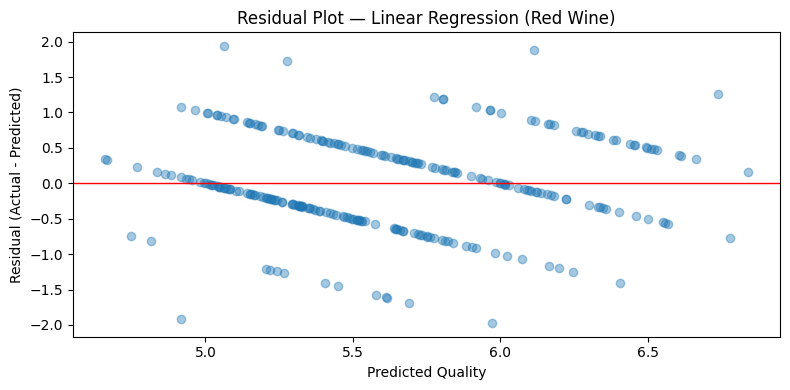

In [ ]:
# Residual plot
residuals = y_test_reg - y_test_pred_lr

plt.figure(figsize=(8, 4))
plt.scatter(y_test_pred_lr, residuals, alpha=0.4)
plt.axhline(0, color="red", linewidth=1)
plt.xlabel("Predicted Quality")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot — Linear Regression (Red Wine)")
plt.tight_layout()
plt.show()

For Linear Regression, the residuals are relatively spread out around the zero line, indicating that prediction errors remain noticeable across different prediction ranges. This suggests that the linear model may not fully capture the complex relationships between physicochemical features and red wine quality.

## Feature coefficients - Linear Regression
For Linear Regression, feature interpretation is performed using regression coefficients because the model assumes a direct linear relationship between the input variables and the target variable. Each coefficient represents the expected change in predicted wine quality for a one-unit increase in the corresponding feature, while holding other variables constant.

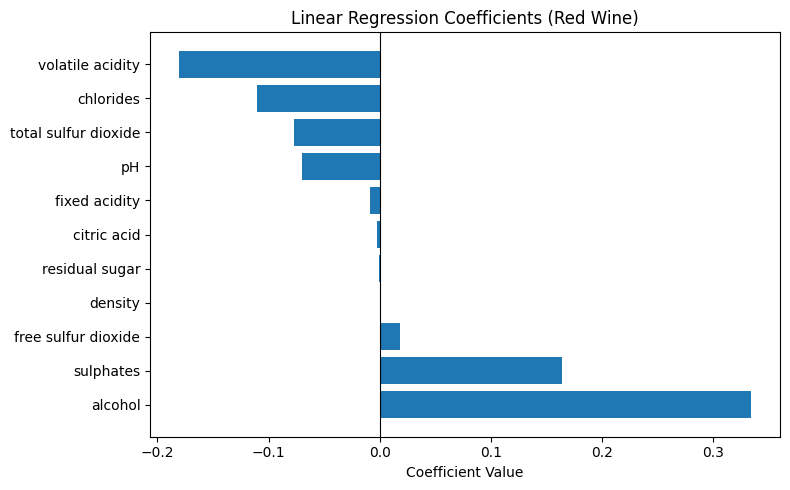

             feature  coefficient
             alcohol     0.334066
           sulphates     0.163919
 free sulfur dioxide     0.018390
             density     0.000019
      residual sugar    -0.000600
         citric acid    -0.002872
       fixed acidity    -0.008838
                  pH    -0.069990
total sulfur dioxide    -0.076881
           chlorides    -0.110886
    volatile acidity    -0.180839


In [ ]:
# Feature coefficients
lr_step = best_lr_reg.named_steps["linreg"]
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": lr_step.coef_
}).sort_values("coefficient", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(coef_df["feature"], coef_df["coefficient"])
plt.axvline(0, color="black", linewidth=0.8)
plt.title(f"Linear Regression Coefficients (Red Wine)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

## Random Forest Regressor

Random Forest Regressor is used as a nonlinear ensemble regression model.  
Unlike Linear Regression, it does not assume a linear relationship between physicochemical features and wine quality. Instead, it builds multiple decision trees and averages their predictions, which helps capture complex feature interactions while reducing variance compared with a single decision tree.

Since Random Forest is tree-based, feature scaling is not required. `GridSearchCV` is used to tune key hyperparameters, and the model is evaluated using RMSE, MAE, and R². Train and test performance are compared to check whether the model is overfitting.

In [ ]:
# Random Forest Regressor
rf_reg = RandomForestRegressor(random_state=42)

# Hyperparameter tuning grid
rf_reg_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.6, 1.0]
}

rf_reg_grid = GridSearchCV(
    estimator=rf_reg,
    param_grid=rf_reg_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rf_reg_grid.fit(X_train, y_train_reg)

print("Best Parameters:", rf_reg_grid.best_params_)
print("Best CV RMSE:", round(np.sqrt(-rf_reg_grid.best_score_), 4))

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best CV RMSE: 0.64


In [ ]:
# Prediction
best_rf_reg = rf_reg_grid.best_estimator_
y_pred_rf_reg = best_rf_reg.predict(X_test)

# Evaluation
rf_reg_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))
rf_reg_mae = mean_absolute_error(y_test_reg, y_pred_rf_reg)
rf_reg_r2 = r2_score(y_test_reg, y_pred_rf_reg)

print(f"RMSE : {rf_reg_rmse:.4f}")
print(f"MAE  : {rf_reg_mae:.4f}")
print(f"R2   : {rf_reg_r2:.4f}")

RMSE : 0.6451
MAE  : 0.5057
R2   : 0.3649


In [ ]:
# Overfitting check
y_train_pred_rf_reg = best_rf_reg.predict(X_train)
y_test_pred_rf_reg = best_rf_reg.predict(X_test)

train_rmse_rf_reg = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_rf_reg))
test_rmse_rf_reg = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_rf_reg))

train_r2_rf_reg = r2_score(y_train_reg, y_train_pred_rf_reg)
test_r2_rf_reg = r2_score(y_test_reg, y_test_pred_rf_reg)

print(f"Train RMSE: {train_rmse_rf_reg:.4f}  |  Test RMSE: {test_rmse_rf_reg:.4f}")
print(f"Train R2  : {train_r2_rf_reg:.4f}  |  Test R2  : {test_r2_rf_reg:.4f}")

Train RMSE: 0.4468  |  Test RMSE: 0.6451
Train R2  : 0.7079  |  Test R2  : 0.3649


## Residual Plot - Random Forest Regressor
For Random Forest Regressor, residual plots help determine whether the tree-based ensemble models are producing consistent predictions across different wine quality levels and whether large prediction errors or bias patterns still exist.

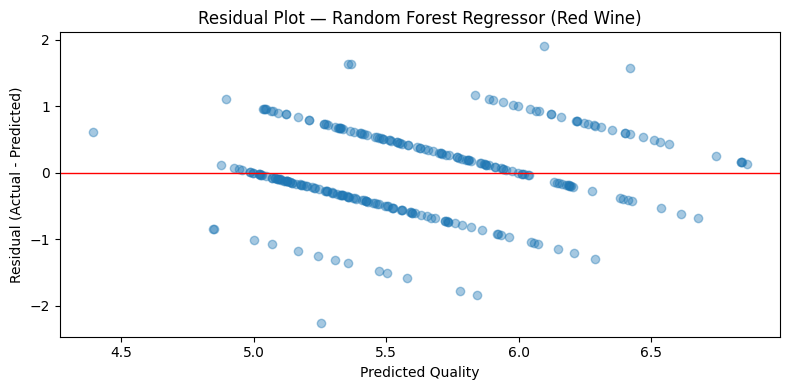

In [ ]:
# Residual plot
residuals_rf_reg = y_test_reg - y_test_pred_rf_reg

plt.figure(figsize=(8, 4))
plt.scatter(y_test_pred_rf_reg, residuals_rf_reg, alpha=0.4)
plt.axhline(0, color="red", linewidth=1)
plt.xlabel("Predicted Quality")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot — Random Forest Regressor (Red Wine)")
plt.tight_layout()
plt.show()

For Random Forest Regressor, the residuals become more concentrated around zero compared to Linear Regression, showing that the model is able to improve prediction accuracy for many wine samples. However, several residual outliers are still present, indicating that prediction errors for certain observations remain relatively large.

## Feature importance - Random Forest Regressor
For Random Forest Regressor, feature importance is used instead because these models are based on ensembles of decision trees rather than linear equations. Feature importance reflects how much each feature contributes to reducing impurity and improving predictive performance throughout the tree-building process.

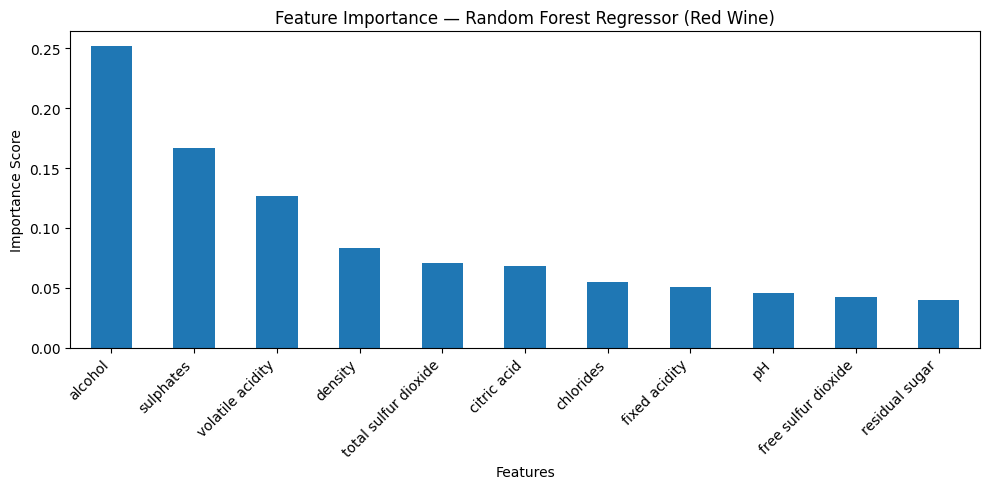

alcohol                 0.251561
sulphates               0.166947
volatile acidity        0.126519
density                 0.083156
total sulfur dioxide    0.070361
citric acid             0.068130
chlorides               0.054991
fixed acidity           0.050527
pH                      0.045495
free sulfur dioxide     0.042554
residual sugar          0.039760
dtype: float64


In [ ]:
# Feature importance - Random Forest Regressor
rf_reg_importance = pd.Series(
    best_rf_reg.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
rf_reg_importance.plot(kind="bar")
plt.title("Feature Importance — Random Forest Regressor (Red Wine)")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(rf_reg_importance)

## Gradient Boosting
Gradient Boosting Regressor is used as an ensemble boosting regression model. Unlike Linear Regression, it does not assume a linear relationship between physicochemical features and wine quality. Instead, it builds multiple weak decision trees sequentially, where each new tree learns from the errors made by the previous trees. This allows the model to capture complex nonlinear relationships and improve prediction accuracy gradually.

Since Gradient Boosting is tree-based, feature scaling is generally not required. `GridSearchCV` is used to tune important hyperparameters such as the number of estimators, learning rate, and maximum tree depth. The model is evaluated using RMSE, MAE, and R² scores. Train and test performance are also compared to analyse whether the model is overfitting.

In [ ]:
# Set hyper parameters for fine tuning
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(
    estimator = GradientBoostingRegressor(random_state=42),
    param_grid = gb_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

gb_grid.fit(X_train, y_train_reg)

print("Best Parameters:", gb_grid.best_params_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


In [ ]:
# use model for prediction
best_gb_reg = gb_grid.best_estimator_

y_pred_gb = best_gb_reg.predict(X_test)

In [ ]:
# evaluation
mse_gb = mean_squared_error(y_test_reg, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
mae_gb = mean_absolute_error(y_test_reg, y_pred_gb)
r2_gb = r2_score(y_test_reg, y_pred_gb)

print("RMSE:", rmse_gb)
print("MAE:", mae_gb)
print("R2:", r2_gb)

RMSE: 0.644051730976427
MAE: 0.5069139473472885
R2: 0.3669810656200211


In [ ]:
# Overfitting checking

# train prediction
y_train_pred_gb = best_gb_reg.predict(X_train)

# test prediction
y_test_pred_gb = best_gb_reg.predict(X_test)

# Train
train_rmse_gb = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_gb))
train_r2_gb = r2_score(y_train_reg, y_train_pred_gb)

# Test
test_rmse_gb = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_gb))
test_r2_gb = r2_score(y_test_reg, y_test_pred_gb)

print(f"Train RMSE: {train_rmse_gb:.4f}  |  Test RMSE: {test_rmse_gb:.4f}")
print(f"Train R2  : {train_r2_gb:.4f}  |  Test R2  : {test_r2_gb:.4f}")

Train RMSE: 0.5388  |  Test RMSE: 0.6441
Train R2  : 0.5752  |  Test R2  : 0.3670


## Residual Plot - Gradient Boosting Regressor
For Gradient Boosting Regressor, residual plots help determine whether the tree-based ensemble models are producing consistent predictions across different wine quality levels and whether large prediction errors or bias patterns still exist.

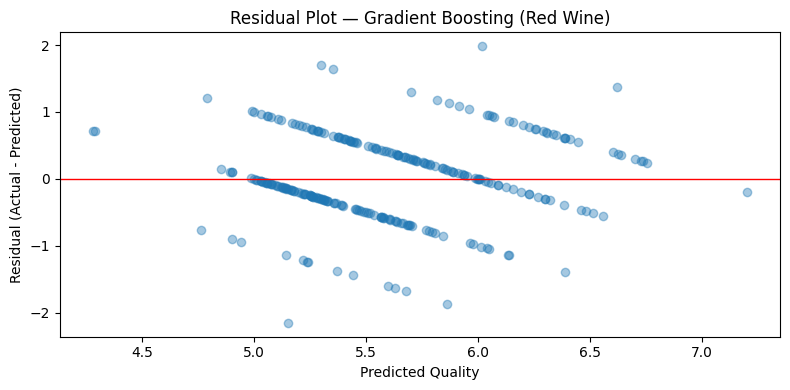

In [ ]:
# Residual plot
residuals = y_test_reg - y_test_pred_gb

plt.figure(figsize=(8, 4))
plt.scatter(y_test_pred_gb, residuals, alpha=0.4)
plt.axhline(0, color="red", linewidth=1)
plt.xlabel("Predicted Quality")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot — Gradient Boosting (Red Wine)")
plt.tight_layout()
plt.show()

For Gradient Boosting Regressor, the residuals appear more evenly distributed around the zero line with a relatively stable spread across prediction ranges. The model shows fewer extreme residual deviations and more balanced prediction behaviour, suggesting stronger generalisation performance on unseen red wine samples.

## Feature importance - Gradient Boosting Regressor
For Gradient Boosting Regressor, feature importance is used instead because these models are based on ensembles of decision trees rather than linear equations. Feature importance reflects how much each feature contributes to reducing impurity and improving predictive performance throughout the tree-building process.

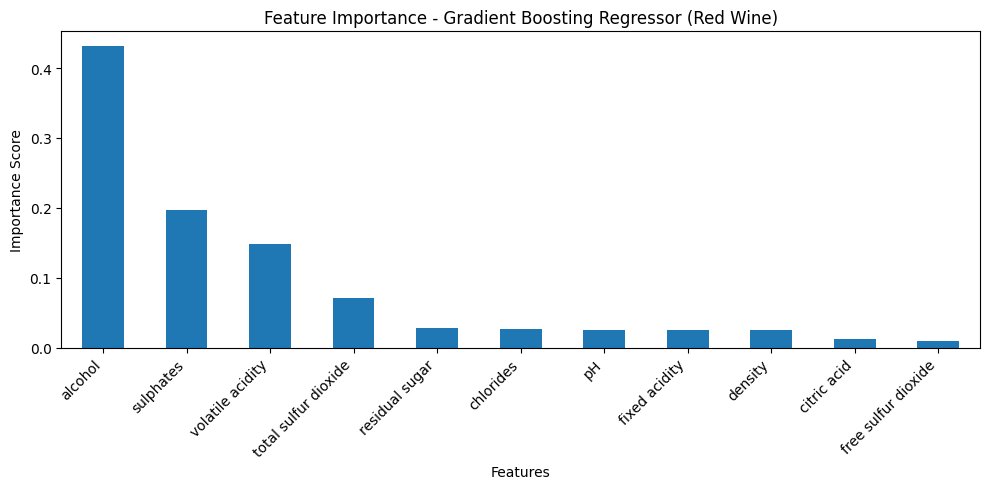

alcohol                 0.430905
sulphates               0.197558
volatile acidity        0.147637
total sulfur dioxide    0.070902
residual sugar          0.027675
chlorides               0.027045
pH                      0.025834
fixed acidity           0.025078
density                 0.024627
citric acid             0.012620
free sulfur dioxide     0.010120
dtype: float64


In [ ]:
# Feature Importance - Gradient Boosting
gb_importance = pd.Series(
    best_gb_reg.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))

gb_importance.plot(kind="bar")

plt.title("Feature Importance - Gradient Boosting Regressor (Red Wine)")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

print(gb_importance)

##From Feature Coefficients and Feature Importance of 3 Models
Across all three models, alcohol consistently appears as the most influential feature related to red wine quality. Sulphates generally show positive influence, while volatile acidity consistently demonstrates negative influence on wine quality prediction. These results suggest that the models identified similar important factors affecting wine quality.

## Regression Model Performance Comparison
A regression model performance comparison table is created to provide a clearer evaluation of the three regression models. Instead of relying on a single metric, multiple evaluation metrics are compared simultaneously to better understand each model’s predictive accuracy and generalisation performance.

RMSE is used to measure the average magnitude of prediction errors, where lower values indicate better prediction accuracy. R² score measures how well the model explains the variance in wine quality, where higher values indicate better model performance.

Both training and testing metrics are included to analyse whether the models are overfitting. A large gap between training and testing performance may indicate that the model memorises the training data but does not generalise well to unseen data.

By comparing Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor together, it becomes easier to identify which model provides the best balance between prediction accuracy and generalisation ability.

In [ ]:
metrics_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor",
        "Gradient Boosting Regressor"
    ],

    "Train RMSE": [
        train_rmse_lr,
        train_rmse_rf_reg,
        train_rmse_gb
    ],

    "Test RMSE": [
        test_rmse_lr,
        test_rmse_rf_reg,
        test_rmse_gb
    ],

    "Train R²": [
        train_r2_lr,
        train_r2_rf_reg,
        train_r2_gb
    ],

    "Test R²": [
        test_r2_lr,
        test_r2_rf_reg,
        test_r2_gb
    ]
})

# round to 4 decimal places
metrics_df = metrics_df.round(4)

print(metrics_df)

                         Model  Train RMSE  Test RMSE  Train R²  Test R²
0            Linear Regression      0.6560     0.6629    0.3703   0.3294
1      Random Forest Regressor      0.4468     0.6451    0.7079   0.3649
2  Gradient Boosting Regressor      0.5388     0.6441    0.5752   0.3670


The comparison table shows that all three regression models achieved relatively similar testing performance, although their training behaviours differ.

Linear Regression produced the most consistent results between training and testing datasets, with Train RMSE (0.6560) and Test RMSE (0.6629) remaining very close. The Train R² (0.3703) and Test R² (0.3294) values are also relatively stable, indicating that the model generalises consistently with minimal overfitting. However, its lower overall R² scores suggest that the linear model may still underfit the dataset and struggle to capture complex nonlinear relationships between wine features and quality.

Random Forest Regressor achieved the strongest training performance with a Train RMSE of 0.4468 and Train R² of 0.7079, showing that the model can fit the training data effectively. Compared to the white wine experiment, the gap between training and testing performance has reduced, suggesting that hyperparameter tuning helped reduce overfitting. However, a noticeable difference still exists between Train R² (0.7079) and Test R² (0.3649), indicating that some overfitting behaviour remains.

Gradient Boosting Regressor achieved the best overall testing performance, with the lowest Test RMSE (0.6441) and highest Test R² (0.3670) among the three models. In addition, the gap between Train R² (0.5752) and Test R² (0.3670) is smaller than Random Forest, indicating better generalisation ability and more balanced learning behaviour.

Overall, Linear Regression demonstrated the most stable behaviour but limited predictive capability, Random Forest achieved strong fitting performance with moderate overfitting, while Gradient Boosting Regressor provided the best balance between prediction accuracy and generalisation performance.

## Discussion (Red Wine)

The red wine quality prediction task was evaluated using both classification and regression approaches. For classification, the original quality scores were regrouped into Low, Medium, and High categories. The class distribution shows moderate imbalance, so macro-F1 is more informative than accuracy because it gives equal importance to each class.

For Logistic Regression, `RobustScaler` was used because several physicochemical features show skewness and potential outliers. For Linear Regression, `StandardScaler` was used because the model is sensitive to feature scale and coefficient magnitude.

The tree-based models, including Random Forest and Gradient Boosting, are expected to perform well because they can capture nonlinear relationships and feature interactions among chemical properties. In contrast, Linear Regression provides a useful baseline for testing how much of the wine quality pattern can be explained by linear relationships.

For classification, most errors are expected to occur between adjacent quality groups, especially Medium and High, because their chemical profiles may overlap and wine quality labels are subjective. For regression, residual plots are used to examine whether prediction errors are randomly distributed or show systematic patterns.
